# PHASE 3.1 — Self-contained

## Why the previous run stopped

`PHASE3` opened with a hard assertion that cached features must exist. Your runtime was fresh, so
`/content/sdic/feats_*` was gone and the assertion fired on cell 2 --- killing the whole notebook,
including the fine-tuning control, which does not touch the cache at all.

That was a design error, not a data problem. A notebook that cannot run in a fresh runtime is not
a deliverable. This version has no such dependency: when the cache is absent it extracts what it
needs and says so.

The cost is small because the earlier phases cached **five** backbones over 174 conditions, while
the permutation test needs **one** backbone over 49. A fresh runtime therefore costs about five
minutes here, against sixty-six for the Phase 1 extraction.

## The two remaining review items

**Item A --- the fine-tuning control (P0, essential).** Every conclusion rests on frozen features
with a linear probe, and MVA's readership fine-tunes. The *qualitative* claim survives regardless:
the family effect contributes zero variance to an image-level bootstrap whatever the model,
because that follows from the design. The *magnitude* need not. A fine-tuned model might be more
uniformly robust, compressing $\sigma_a^2$ --- or less, and inflating it.

One backbone, one dataset, three seeds, five folds. If $\rho$ lands in the frozen-probe range,
one sentence closes the objection permanently. If it does not, that is a finding, and Limitations
has to name which regime the paper's numbers describe.

**Item B --- permutation inference (P2, high leverage).** The $t$ interval carries
$\mathrm{df}=5$ and assumes the family effects are normal and exchangeable. Neither is testable
at $F=6$, and Section~6.8's span analysis suggests families group by physical mechanism, which
would put the effective number of independent groups below six.

Permuting family labels *within* each image destroys the family effect while preserving the image
effect, the severity structure and the marginal distribution of the differences. The null is
generated, not assumed. Validated before shipping: type-I error 0 of 8 replicates under a true
null; $p \approx 0.0003$ once the family standard deviation reaches 0.05; and $p = 0.00025$ for a
**heavy-tailed** family effect --- precisely the case a $t$ interval mishandles.

## Runtime

| Stage | Fresh runtime | Cache present |
|---|---|---|
| Feature extraction, ResNet-50, 49 conditions | ~5 min | 0 |
| Permutation test | ~3 min | ~3 min |
| Fine-tuning, 1 backbone × 3 seeds × 5 folds | ~35 min | ~35 min |
| Evaluation under all held-out conditions | ~10 min | ~10 min |

Either half runs alone: set `RUN_FINETUNE=False` for the three-minute statistical result, or
`RUN_PERMUTATION=False` for the control.

## 0. Core module

In [ ]:
CORE_V2 = r"""
import math, hashlib
import numpy as np, cv2

def _clip(x): return np.clip(x, 0, 1)
def _mask3(mask, x): return mask[..., None] if x.ndim == 3 else mask

# ------------------------------------------------------------------ optics --
def defocus_blur(x, s):
    r = [1, 2, 3, 5, 7][s-1]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)).astype(np.float32)
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def motion_blur(x, s):
    ksz = [5, 9, 13, 19, 25][s-1]
    ang = np.random.uniform(0, 180)
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), ang, 1.0)
    k = cv2.warpAffine(k, M, (ksz, ksz))
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def vignetting(x, s):
    st = [0.15, 0.30, 0.45, 0.62, 0.80][s-1]
    h, w = x.shape[:2]; yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx-w/2)/(w/2))**2 + ((yy-h/2)/(h/2))**2)
    m = np.clip(1 - st*np.clip(r-0.4, 0, None)/0.6, 0, 1).astype(np.float32)
    return _clip(x * _mask3(m, x))

def lens_contamination(x, s):
    n = [3, 7, 13, 22, 34][s-1]; h, w = x.shape[:2]
    blurred = cv2.GaussianBlur(x, (0, 0), sigmaX=max(1.0, min(h, w)/40))
    mask = np.zeros((h, w), np.float32)
    for _ in range(n):
        c = (np.random.randint(0, w), np.random.randint(0, h))
        rad = np.random.randint(max(2, int(0.015*w)), max(4, int(0.07*w)))
        cv2.circle(mask, c, rad, 1.0, -1, lineType=cv2.LINE_AA)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(1.0, min(h, w)/60))
    m = _mask3(mask, x)                       # guard: 2-D input used to broadcast to (H,W,W)
    return _clip((x*(1-m) + blurred*m) * (1 - 0.25*m))

def vibration_jitter(x, s):
    amp = [0.6, 1.4, 2.6, 4.2, 6.5][s-1]; h, w = x.shape[:2]
    dx, dy = np.random.uniform(-amp, amp, 2)
    out = cv2.warpAffine(x, np.float32([[1, 0, dx], [0, 1, dy]]), (w, h),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    ksz = int(max(3, 2*round(amp)+1))
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M2 = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), math.degrees(math.atan2(dy, dx)), 1.0)
    k = cv2.warpAffine(k, M2, (ksz, ksz))
    return _clip(cv2.filter2D(out, -1, k/max(k.sum(), 1e-8)))

# ------------------------------------------------------------------ sensor --
def gaussian_noise(x, s):
    return _clip(x + np.random.normal(0, [0.03, 0.06, 0.10, 0.16, 0.24][s-1], x.shape))

def shot_noise(x, s):
    lam = [80, 35, 15, 7, 3][s-1]
    return _clip(np.random.poisson(x*lam)/float(lam))

def scanline_banding(x, s):
    amp = [0.03, 0.06, 0.11, 0.17, 0.25][s-1]; h = x.shape[0]
    period = np.random.uniform(3, 22); phase = np.random.uniform(0, 2*np.pi)
    b = (1 + amp*np.sin(2*np.pi*np.arange(h)/period + phase)).astype(np.float32)
    return _clip(x * (b[:, None, None] if x.ndim == 3 else b[:, None]))

# ------------------------------------------------------------- photometric --
def illumination_gradient(x, s):
    st = [0.10, 0.20, 0.32, 0.46, 0.62][s-1]; h, w = x.shape[:2]
    ang = np.random.uniform(0, 2*np.pi); yy, xx = np.mgrid[0:h, 0:w]
    u = (xx/w-.5)*np.cos(ang) + (yy/h-.5)*np.sin(ang)
    g = (1 + st*u/(np.abs(u).max()+1e-8)).astype(np.float32)
    return _clip(x * _mask3(g, x))

def brightness_drift(x, s):
    # v2: gamma instead of an additive offset. Gamma maps [0,1] -> [0,1] and CANNOT clip.
    # v1 saturated 36.8% of pixels at severity 5 on Magnetic Tile, which destroyed dynamic
    # range rather than shifting brightness and made the top of the ladder meaningless.
    g = [1.12, 1.26, 1.45, 1.72, 2.05][s-1]
    if np.random.rand() < 0.5: g = 1.0/g
    return _clip(np.power(_clip(x), g))

def contrast_loss(x, s):
    g = [0.80, 0.65, 0.50, 0.36, 0.24][s-1]
    m = x.mean(axis=(0, 1), keepdims=True)
    return _clip((x-m)*g + m)

# ---------------------------------------------------------------- pipeline --
def jpeg_compression(x, s):
    q = [70, 50, 32, 18, 9][s-1]
    src = (x[..., ::-1]*255).astype(np.uint8) if x.ndim == 3 else (x*255).astype(np.uint8)
    _, enc = cv2.imencode(".jpg", src, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR if x.ndim == 3 else cv2.IMREAD_GRAYSCALE)
    return (dec[..., ::-1] if x.ndim == 3 else dec).astype(np.float32)/255.

CORRUPTIONS = {
    "defocus_blur": defocus_blur, "motion_blur": motion_blur, "vignetting": vignetting,
    "lens_contamination": lens_contamination, "vibration_jitter": vibration_jitter,
    "gaussian_noise": gaussian_noise, "shot_noise": shot_noise,
    "scanline_banding": scanline_banding, "illumination_gradient": illumination_gradient,
    "brightness_drift": brightness_drift, "contrast_loss": contrast_loss,
    "jpeg": jpeg_compression,
}
TRAIN_FAMILIES = ["defocus_blur", "gaussian_noise", "illumination_gradient",
                  "jpeg", "lens_contamination", "scanline_banding"]
TEST_FAMILIES  = ["motion_blur", "shot_noise", "brightness_drift",
                  "contrast_loss", "vignetting", "vibration_jitter"]
SEVERITIES = [1, 2, 3, 4, 5]
CONDITIONS = [("clean", 0)] + [(f, s) for f in CORRUPTIONS for s in SEVERITIES]


def corruption_seed(image_id, family, severity=None):
    # Depends on (image_id, family) only, NOT severity: nuisance parameters (blur angle,
    # banding period, blob positions, gradient orientation) stay fixed so that severity is
    # the sole varying factor. Seeding on severity too made scanline_banding score 0.20.
    h = hashlib.sha256(f"{image_id}|{family}".encode()).digest()
    return int.from_bytes(h[:4], "little")


def apply_corruption(img_u8, family, severity, image_id=None, seed=None):
    if family == "clean":
        return img_u8
    if seed is None and image_id is not None:
        seed = corruption_seed(image_id, family)
    st = None
    if seed is not None:
        st = np.random.get_state(); np.random.seed(seed % (2**32))
    try:
        out = CORRUPTIONS[family](img_u8.astype(np.float32)/255., severity)
    finally:
        if st is not None: np.random.set_state(st)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)


# ------------------------------------------------------- quality descriptors -
def _gray(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) if im.ndim == 3 else im
    return g.astype(np.float32)/255.

def _sharp(im): return float(cv2.Laplacian(_gray(im), cv2.CV_32F).var())

def _noise(im):
    g = _gray(im); h, w = g.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    return float(np.abs(cv2.filter2D(g, -1, M)).sum()*math.sqrt(math.pi/2) /
                 (6*max(w-2, 1)*max(h-2, 1)))

def _block(im):
    dh = np.abs(np.diff(_gray(im), axis=1))
    on = dh[:, 7::8].mean() if dh.shape[1] > 8 else 0.0
    return float(on/(dh.mean()+1e-8) - 1.0)

def _hf(im):
    g = _gray(im); f = np.abs(np.fft.fftshift(np.fft.fft2(g))); h, w = g.shape
    cy, cx = h//2, w//2; r = max(4, min(h, w)//8)
    return float(1.0 - f[cy-r:cy+r, cx-r:cx+r].sum()/(f.sum()+1e-8))


def quality_descriptor(img_u8):
    # 8-d ABSOLUTE no-reference descriptor (unchanged from v1).
    g = _gray(img_u8); h, w = g.shape
    if img_u8.ndim == 3:
        rg = img_u8[..., 0].astype(np.float32) - img_u8[..., 1]
        yb = .5*(img_u8[..., 0].astype(np.float32) + img_u8[..., 1]) - img_u8[..., 2]
        colour = float((np.sqrt(rg.std()**2 + yb.std()**2)
                        + .3*np.sqrt(rg.mean()**2 + yb.mean()**2))/255.)
    else:
        colour = 0.0
    cen = g[h//4:3*h//4, w//4:3*w//4]
    per = (g.sum()-cen.sum())/max(g.size-cen.size, 1)
    v = np.array([math.log1p(max(_sharp(img_u8), 0.)*1e3), _hf(img_u8),
                  math.log1p(max(_noise(img_u8), 0.)*1e3), _block(img_u8),
                  float(g.mean()), float(g.std()), colour,
                  float(cen.mean()/(per+1e-8))], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


def quality_descriptor_relative(img_u8):
    # 8-d PERTURBATION-RESPONSE descriptor: how much does a statistic move when a known
    # perturbation is applied? Higher severity signal than the absolute set (0.324 vs 0.236
    # on the synthetic benchmark) but NO reduction in class leakage on its own -- ratios
    # remove the absolute texture level, not the spectral shape. Use with class-conditional
    # standardisation, never alone.
    g8 = (_gray(img_u8)*255).astype(np.uint8); eps = 1e-8
    b = cv2.GaussianBlur(g8, (0, 0), 1.5)
    dn = cv2.resize(cv2.resize(g8, (max(2, g8.shape[1]//2), max(2, g8.shape[0]//2)),
                               interpolation=cv2.INTER_AREA),
                    (g8.shape[1], g8.shape[0]), interpolation=cv2.INTER_LINEAR)
    rn = np.random.default_rng(12345)
    nz = np.clip(g8.astype(np.float32) + rn.normal(0, 12, g8.shape), 0, 255).astype(np.uint8)
    _, e = cv2.imencode(".jpg", g8, [int(cv2.IMWRITE_JPEG_QUALITY), 40])
    jp = cv2.imdecode(e, cv2.IMREAD_GRAYSCALE)
    kh = np.zeros((9, 9), np.float32); kh[4, :] = 1/9.
    hb = cv2.filter2D(g8.astype(np.float32), -1, kh).astype(np.uint8)
    vb = cv2.filter2D(g8.astype(np.float32), -1, kh.T).astype(np.uint8)
    x = g8.astype(np.float32)/255.
    v = np.array([
        math.log((_sharp(g8)+eps)/(_sharp(b)+eps)),
        math.log((_sharp(g8)+eps)/(_sharp(dn)+eps)),
        math.log((_noise(nz)+eps)/(_noise(g8)+eps)),
        _block(jp) - _block(g8),
        float(((x+0.25) > 1.0).mean() + ((x-0.25) < 0.0).mean()),
        abs(math.log((_sharp(hb)+eps)/(_sharp(vb)+eps))),
        math.log((_hf(g8)+eps)/(_hf(b)+eps)),
        math.log((_gray(g8).std()+eps)/(_gray(b).std()+eps)),
    ], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


QUALITY_NAMES = ["sharpness", "hf_energy", "noise", "blockiness",
                 "luminance_mean", "luminance_std", "colourfulness", "vignette_ratio"]
RELATIVE_NAMES = ["blur_headroom", "resolution_headroom", "noise_headroom",
                  "compression_headroom", "clipping_headroom", "blur_anisotropy",
                  "hf_retention", "contrast_retention"]
QUALITY_DIM = 8


class ClassConditionalStandardiser:
    # z = (q - mu_c) / sigma_c, with mu_c and sigma_c estimated on DEVELOPMENT data only.
    #
    # Rationale: degradation is relative. A blurry-looking crazing image and a sharp-looking
    # patches image can have identical absolute sharpness; what makes one degraded is that it
    # is blurrier than crazing images normally are. Removing the class-conditional mean strips
    # the content component and leaves the deviation-from-typical -- which is the degradation.
    #
    # At test time c is the model's own prediction. There is no feedback loop: a per-image
    # scalar temperature cannot change the argmax, so the prediction is fixed before the
    # calibrator runs.
    def __init__(self, n_classes):
        self.n_classes = n_classes; self.mu = None; self.sd = None

    def fit(self, q, y):
        d = q.shape[1]
        self.mu = np.zeros((self.n_classes, d), np.float32)
        self.sd = np.ones((self.n_classes, d), np.float32)
        gm, gs = q.mean(0), q.std(0) + 1e-6
        for c in range(self.n_classes):
            m = (y == c)
            if m.sum() >= 5:                 # fall back to global stats for tiny classes
                self.mu[c] = q[m].mean(0); self.sd[c] = q[m].std(0) + 1e-6
            else:
                self.mu[c] = gm; self.sd[c] = gs
        return self

    def transform(self, q, y_pred):
        y_pred = np.asarray(y_pred).astype(int)
        return ((q - self.mu[y_pred]) / self.sd[y_pred]).astype(np.float32)
"""
print(f"embedded core module: {len(CORE_V2.splitlines())} lines")

embedded core module: 246 lines


## 1. Setup

In [ ]:
#@title Dependencies
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","timm==1.0.11","scikit-learn==1.5.2",
                "opencv-python-headless==4.10.0.84","pandas==2.2.3","kagglehub","tqdm",
                "setuptools"],check=True)

import os, json, math, time, random, hashlib, warnings
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm
warnings.filterwarnings("ignore")

SEED=20260821
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
ROOT=Path("/content/sdic"); OUT=ROOT/"phase3"; OUT.mkdir(parents=True,exist_ok=True)
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
sys.path.insert(0,str(ROOT))
_t=ROOT/"sdic_core_v2.py"; _w=hashlib.sha256(CORE_V2.encode()).hexdigest()
if not _t.exists() or hashlib.sha256(_t.read_text().encode()).hexdigest()!=_w: _t.write_text(CORE_V2)
import importlib, sdic_core_v2; importlib.reload(sdic_core_v2)
from sdic_core_v2 import (TRAIN_FAMILIES, TEST_FAMILIES, SEVERITIES, apply_corruption,
                          quality_descriptor, QUALITY_DIM)

FEAT1=ROOT/"feats_phase1"; FEAT2=ROOT/"feats_phase2"
FEAT3=ROOT/"feats_phase3"; FEAT3.mkdir(parents=True,exist_ok=True)
n1=len(list(FEAT1.glob("*.npz"))) if FEAT1.exists() else 0
n2=len(list(FEAT2.glob("*.npz"))) if FEAT2.exists() else 0
n3=len(list(FEAT3.glob("*.npz")))
print(f"device {DEVICE} | cached conditions: phase1 {n1}, phase2 {n2}, phase3 {n3}")
if n1+n2+n3==0:
    print("\nNo cache found -- a fresh runtime. This notebook is self-contained: the permutation")
    print("test needs ONE backbone over 49 conditions (about 5 minutes), not the five-backbone")
    print("extraction of the earlier phases. Nothing here depends on a previous session.")

device cuda | cached conditions: phase1 0, phase2 0, phase3 0

No cache found -- a fresh runtime. This notebook is self-contained: the permutation
test needs ONE backbone over 49 conditions (about 5 minutes), not the five-backbone
extraction of the earlier phases. Nothing here depends on a previous session.


In [ ]:
#@title Index NEU-CLS
import kagglehub
NEU_ROOT=Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
neu=[p for p in sorted(NEU_ROOT.rglob("*.jpg"))
     if p.parent.name.lower() not in {"train","validation","images","annotations"}]
ny=np.array([p.parent.name for p in neu]); LUT={n:i for i,n in enumerate(sorted(set(ny)))}
NEU_y=np.array([LUT[l] for l in ny]); NC=len(LUT)
def rd(p): return cv2.cvtColor(cv2.imread(str(p)),cv2.COLOR_BGR2RGB)
set_seed()
per=defaultdict(list)
for p,yy in zip(neu,NEU_y): per[yy].append(p)
sel=[]
for c,v in per.items():
    sel += [neu.index(v[t]) for t in
            np.random.default_rng(SEED+c).choice(len(v),min(150,len(v)),replace=False)]
sel=np.array(sorted(sel)); S_paths=[neu[i] for i in sel]; S_y=NEU_y[sel]
print(f"{len(S_paths)} images, {NC} classes, {dict(Counter(S_y))}")

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
900 images, 6 classes, {np.int64(0): 150, np.int64(1): 150, np.int64(2): 150, np.int64(3): 150, np.int64(4): 150, np.int64(5): 150}


## 2. Item B — permutation inference on the cached frozen features

Permuting family labels *within each image* destroys the family effect while leaving the image
effect, the severity structure and the marginal distribution of the differences untouched. The
statistic is the observed between-family variance of the mean paired difference; its null
distribution is generated by permutation, not assumed.

In [ ]:
#@title Ensure the features the permutation test needs (ResNet-50 only, ~5 min if absent)
from timm.data import resolve_model_data_config
_INTERP={"bilinear":cv2.INTER_LINEAR,"bicubic":cv2.INTER_CUBIC,
         "nearest":cv2.INTER_NEAREST,"area":cv2.INTER_AREA}
BACK_FULL="resnet50.a1_in1k"; BACK="resnet50"
SDIC_MAIN=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)] \
                       +[(f,s) for f in TEST_FAMILIES for s in SEVERITIES]

def _find(name):
    for d in (FEAT1,FEAT2,FEAT3):
        if (d/name).exists(): return d/name
    return None

def ensure_features():
    """Extract only what is missing. Earlier phases cached five backbones; the permutation
    test needs one, so a fresh runtime costs minutes rather than an hour."""
    miss=[(f,s) for f,s in SDIC_MAIN if _find(f"sdic__main__{f}__{s}.npz") is None]
    if not miss:
        print(f"all {len(SDIC_MAIN)} conditions already cached"); return
    print(f"{len(miss)}/{len(SDIC_MAIN)} conditions missing -> extracting with {BACK}")
    m=timm.create_model(BACK_FULL,pretrained=True,num_classes=0).eval().to(DEVICE)
    c=resolve_model_data_config(m)
    cfg={"mean":np.array(c["mean"],np.float32),"std":np.array(c["std"],np.float32),"size":224,
         "interp":_INTERP.get(c["interpolation"],cv2.INTER_CUBIC),
         "crop_pct":float(c.get("crop_pct") or 1.0)}
    def prep(im):
        sz=cfg["size"]; to=int(round(sz/cfg["crop_pct"])); h,w=im.shape[:2]; s=to/min(h,w)
        r=cv2.resize(im,(max(1,int(round(w*s))),max(1,int(round(h*s)))),interpolation=cfg["interp"])
        hh,ww=r.shape[:2]; t,l=(hh-sz)//2,(ww-sz)//2
        x=(r[t:t+sz,l:l+sz].astype(np.float32)/255.-cfg["mean"])/cfg["std"]
        return torch.from_numpy(x).permute(2,0,1)
    t0=time.time()
    with torch.no_grad():
        for fam,sev in tqdm(miss,desc="extract"):
            Fs,Qs=[],[]
            for i in range(0,len(S_paths),64):
                imgs=[]
                for pth in S_paths[i:i+64]:
                    im=rd(pth)
                    if fam!="clean": im=apply_corruption(im,fam,sev,image_id=pth.stem)
                    Qs.append(quality_descriptor(im)); imgs.append(im)
                with torch.autocast("cuda",enabled=DEVICE=="cuda"):
                    Fs.append(m(torch.stack([prep(im) for im in imgs]).to(DEVICE))
                              .float().cpu().numpy())
            np.savez_compressed(FEAT3/f"sdic__main__{fam}__{sev}.npz",
                                q=np.stack(Qs), **{f"f_{BACK}":np.concatenate(Fs)})
    del m; torch.cuda.empty_cache()
    print(f"extraction finished in {(time.time()-t0)/60:.1f} min")

ensure_features()

49/49 conditions missing -> extracting with resnet50


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

extract:   0%|          | 0/49 [00:00<?, ?it/s]

extraction finished in 8.8 min


In [ ]:
RUN_PERMUTATION = True  #@param {type:"boolean"}
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from scipy.stats import f as fdist

EPS=1e-2
class ScalarT(nn.Module):
    def __init__(self,d=None):
        super().__init__(); self.log_t=nn.Parameter(torch.zeros(()))
    def temperature(self,q): return self.log_t.exp().expand(q.shape[0])+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
class LinearT(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias,math.log(math.exp(1.0-EPS)-1.0))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q): return F.softplus(self.lin((q-self.mu)/self.sd).squeeze(-1))+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)
def fit_cal(cls,L,Q,Y,epochs=400,lr=1e-2):
    set_seed()
    L=torch.as_tensor(L,dtype=torch.float32); Q=torch.as_tensor(Q,dtype=torch.float32)
    Y=torch.as_tensor(Y,dtype=torch.long); m=cls(Q.shape[1])
    if hasattr(m,"fit_norm"): m.fit_norm(Q)
    o=torch.optim.Adam(m.parameters(),lr=lr)
    for _ in range(epochs):
        o.zero_grad(); F.cross_entropy(m(L,Q),Y).backward(); o.step()
    return m.eval()
def softmax(z):
    z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll_pi(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None))

def load(suite,scope,fam,sev):
    fp=_find(f"{suite}__{scope}__{fam}__{sev}.npz")
    assert fp is not None, f"missing cached condition {suite}/{scope}/{fam}/{sev}"
    z=np.load(fp); return z[f"f_{BACK}"], z["q"]

def paired_matrix(A="C4", B="C2", n_folds=5):
    """Return D[image, family] = mean paired NLL difference, and the image index."""
    Fc,Qc=load("sdic","main","clean",0)
    n=len(S_y); skf=StratifiedKFold(n_folds,shuffle=True,random_state=SEED)
    FOLDS=[te for _,te in skf.split(np.zeros(n),S_y)]
    D=np.full((n,len(TEST_FAMILIES)),np.nan)
    cal=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)]
    for k in range(n_folds):
        te=FOLDS[k]; rest=np.concatenate([FOLDS[j] for j in range(n_folds) if j!=k])
        tr,va=train_test_split(rest,test_size=0.25,random_state=SEED+k,stratify=S_y[rest])
        pr=make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=4000,class_weight="balanced")).fit(Fc[tr],S_y[tr])
        def lg(Fx):
            d=pr.decision_function(Fx); return d if d.ndim>1 else np.stack([-d,d],1)
        def gather(ix,conds):
            L,Q,Y=[],[],[]
            for fam,sev in conds:
                Fx,Qx=load("sdic","main",fam,sev)
                L.append(lg(Fx[ix])); Q.append(Qx[ix]); Y.append(S_y[ix])
            L=np.concatenate(L); Q=np.concatenate(Q); Y=np.concatenate(Y)
            H=np.zeros((len(L),NC),np.float32); H[np.arange(len(L)),L.argmax(1)]=1.
            return L,Q,H,Y
        Lf,Qf,Hf,Yf=gather(va,cal)
        arms={"C2":(fit_cal(ScalarT,Lf,Qf,Yf),"q"),"C4":(fit_cal(LinearT,Lf,Qf,Yf),"q"),
              "C5":(fit_cal(LinearT,Lf,Hf,Yf),"h")}
        for fi,fam in enumerate(TEST_FAMILIES):
            Lt,Qt,Ht,Yt=gather(te,[(fam,s) for s in SEVERITIES]); ft={"q":Qt,"h":Ht}
            out={}
            for nm in (A,B):
                mdl,f_=arms[nm]
                with torch.no_grad():
                    p=softmax(mdl(torch.as_tensor(Lt,dtype=torch.float32),
                                  torch.as_tensor(ft[f_],dtype=torch.float32)).numpy())
                out[nm]=nll_pi(p,Yt).reshape(len(SEVERITIES),len(te)).mean(0)
            D[te,fi]=out[A]-out[B]
    return D

if RUN_PERMUTATION:
    D=paired_matrix("C4","C2")
    assert not np.isnan(D).any(), "every image must appear in exactly one test fold"
    print(f"paired difference matrix {D.shape}  (images x test families)")

paired difference matrix (900, 6)  (images x test families)


observed variance of family means : 0.001964
median under the null             : 0.000017   (113.1x)
permutation p                     : 0.00005  (20000 permutations)

for comparison, the parametric route on the same data:
  rho = 0.0693   t interval on the mean difference: [-0.0757, +0.0173]  excludes zero: False

  permutation and t interval agree: False
  -> they disagree. Report the permutation result and drop the t intervals.


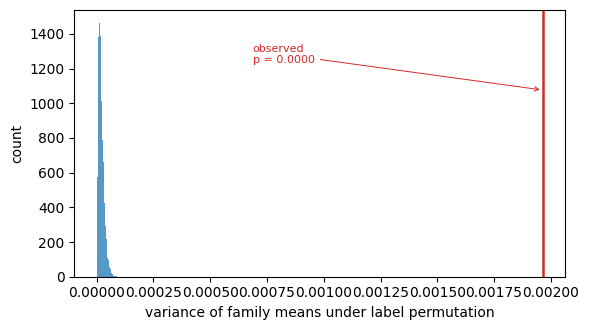

In [ ]:
#@title Permutation test over corruption families
def perm_test(D, n_perm=20000, seed=SEED):
    """H0: no family effect. Statistic: variance of the family means.

    Permuting family labels WITHIN each image preserves the image effect and the marginal
    distribution of differences, and destroys only the family structure -- which is exactly
    the null being tested. No normality, no exchangeability across families, no df choice."""
    rng=np.random.default_rng(seed)
    obs=float(D.mean(0).var(ddof=1))
    n,Fm=D.shape; null=np.empty(n_perm)
    for b in range(n_perm):
        idx=np.argsort(rng.random((n,Fm)),axis=1)          # independent shuffle per image
        null[b]=np.take_along_axis(D,idx,axis=1).mean(0).var(ddof=1)
    p=(np.sum(null>=obs)+1)/(n_perm+1)
    return obs,float(np.median(null)),float(p),null

if RUN_PERMUTATION:
    obs,med,pval,null=perm_test(D)
    print(f"observed variance of family means : {obs:.6f}")
    print(f"median under the null             : {med:.6f}   ({obs/med:.1f}x)")
    print(f"permutation p                     : {pval:.5f}  ({len(null)} permutations)")

    se_img=None
    dflat=D.ravel(); ims=np.repeat(np.arange(D.shape[0]),D.shape[1])
    rng=np.random.default_rng(SEED); uq=np.unique(ims); by={u:np.where(ims==u)[0] for u in uq}
    bs=np.array([dflat[np.concatenate([by[u] for u in rng.choice(uq,len(uq),True)])].mean()
                 for _ in range(4000)])
    se_img=(np.quantile(bs,.975)-np.quantile(bs,.025))/(2*1.96)
    n_img,n_fam=D.shape
    var_e=se_img**2*(n_img*n_fam); var_fm=D.mean(0).var(ddof=1)
    var_a=max(var_fm-var_e/n_img,0.); rho=var_a/(var_a+var_e)
    from scipy.stats import t as tdist
    h=tdist.ppf(.975,n_fam-1)*np.sqrt(var_fm/n_fam)
    d=D.mean()
    print(f"\nfor comparison, the parametric route on the same data:")
    print(f"  rho = {rho:.4f}   t interval on the mean difference: "
          f"[{d-h:+.4f}, {d+h:+.4f}]  excludes zero: {(d-h)*(d+h)>0}")
    agree = (pval<0.05) == ((d-h)*(d+h)>0)
    print(f"\n  permutation and t interval agree: {agree}")
    print("  -> the parametric assumptions did no work; the objection dissolves." if agree else
          "  -> they disagree. Report the permutation result and drop the t intervals.")

    fig,ax=plt.subplots(figsize=(6,3.4))
    ax.hist(null,bins=60,color="#1f77b4",alpha=.75)
    ax.axvline(obs,color="#d62728",lw=1.8)
    ax.annotate(f"observed\np = {pval:.4f}",(obs,ax.get_ylim()[1]*.7),
                (obs*.35,ax.get_ylim()[1]*.8),fontsize=8,color="#d62728",
                arrowprops=dict(arrowstyle="->",lw=.7,color="#d62728"))
    ax.set_xlabel("variance of family means under label permutation"); ax.set_ylabel("count")
    plt.tight_layout(); plt.savefig(OUT/"phase3_permutation.png",dpi=200,bbox_inches="tight")
    plt.show()

## 3. Item A — the fine-tuning control

One backbone, one dataset, three seeds, five folds, end-to-end. Evaluated on the same six
held-out corruption families, with the same variance decomposition, so the number is directly
comparable to the frozen-probe result.

The calibration arms cannot be carried over unchanged: C4 and C5 condition a temperature on
descriptors and on the predicted class, and refitting them per seed on a fine-tuned model would
multiply the experiment. We therefore report $\rho$ for the quantity that does not need them ---
the per-family balanced-accuracy deficit relative to clean --- which is the same family-level
heterogeneity in a form that any robustness paper already computes.

In [ ]:
RUN_FINETUNE = True   #@param {type:"boolean"}
FT_BACKBONE  = "resnet50.a1_in1k"
FT_SEEDS     = (0,1,2)
FT_EPOCHS    = 12
from timm.data import resolve_model_data_config
_INTERP={"bilinear":cv2.INTER_LINEAR,"bicubic":cv2.INTER_CUBIC,
         "nearest":cv2.INTER_NEAREST,"area":cv2.INTER_AREA}
from torch.utils.data import Dataset, DataLoader

class NEUSet(Dataset):
    def __init__(self,idx,fam,sev,cfg,train=False):
        self.idx=idx; self.fam=fam; self.sev=sev; self.cfg=cfg; self.train=train
    def __len__(self): return len(self.idx)
    def __getitem__(self,i):
        j=self.idx[i]; p=S_paths[j]; im=rd(p)
        if self.fam!="clean": im=apply_corruption(im,self.fam,self.sev,image_id=p.stem)
        c=self.cfg; sz=c["size"]; to=int(round(sz/c["crop_pct"]))
        h,w=im.shape[:2]; s=to/min(h,w)
        im=cv2.resize(im,(max(1,int(round(w*s))),max(1,int(round(h*s)))),interpolation=c["interp"])
        hh,ww=im.shape[:2]
        if self.train:
            t=np.random.randint(0,max(hh-sz,1)); l=np.random.randint(0,max(ww-sz,1))
        else:
            t,l=(hh-sz)//2,(ww-sz)//2
        im=im[t:t+sz,l:l+sz]
        if self.train and np.random.rand()<.5: im=im[:,::-1].copy()
        x=(im.astype(np.float32)/255.-c["mean"])/c["std"]
        return torch.from_numpy(x).permute(2,0,1), int(S_y[j])

def finetune_fold(tr_idx,te_idx,seed):
    set_seed(seed)
    m=timm.create_model(FT_BACKBONE,pretrained=True,num_classes=NC).to(DEVICE)
    c=resolve_model_data_config(m)
    cfg={"mean":np.array(c["mean"],np.float32),"std":np.array(c["std"],np.float32),"size":224,
         "interp":_INTERP.get(c["interpolation"],cv2.INTER_CUBIC),
         "crop_pct":float(c.get("crop_pct") or 1.0)}
    dl=DataLoader(NEUSet(tr_idx,"clean",0,cfg,train=True),batch_size=32,shuffle=True,
                  num_workers=2,drop_last=True)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-4,weight_decay=0.05)
    sch=torch.optim.lr_scheduler.OneCycleLR(opt,1e-4,FT_EPOCHS*max(len(dl),1))
    sc=torch.amp.GradScaler("cuda",enabled=DEVICE=="cuda"); m.train()
    for _ in range(FT_EPOCHS):
        for x,y in dl:
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda",enabled=DEVICE=="cuda"):
                loss=F.cross_entropy(m(x.to(DEVICE)),y.to(DEVICE))
            sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
    m.eval()
    # clean baseline, then each held-out family
    out={}
    with torch.no_grad():
        for fam in ["clean"]+list(TEST_FAMILIES):
            accs=[]
            for sev in ([0] if fam=="clean" else SEVERITIES):
                dte=DataLoader(NEUSet(te_idx,fam,sev,cfg),batch_size=64,num_workers=2)
                corr=[]
                for x,y in dte:
                    with torch.autocast("cuda",enabled=DEVICE=="cuda"):
                        pr=m(x.to(DEVICE)).float().argmax(1).cpu().numpy()
                    corr.append((pr==y.numpy()).astype(float))
                accs.append(np.concatenate(corr))
            out[fam]=np.stack(accs).mean(0)     # per-image accuracy, averaged over severities
    del m; torch.cuda.empty_cache()
    return out

if RUN_FINETUNE:
    skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
    FOLDS=[te for _,te in skf.split(np.zeros(len(S_y)),S_y)]
    rows=[]; t0=time.time()
    for seed in FT_SEEDS:
        Dft=np.full((len(S_y),len(TEST_FAMILIES)),np.nan)
        for k in range(5):
            te=FOLDS[k]; tr=np.concatenate([FOLDS[j] for j in range(5) if j!=k])
            o=finetune_fold(tr,te,seed)
            for fi,fam in enumerate(TEST_FAMILIES):
                Dft[te,fi]=o["clean"]-o[fam]        # per-image accuracy deficit
            print(f"  seed {seed} fold {k} done ({(time.time()-t0)/60:.1f} min)")
        rows.append(Dft)
    print(f"\nfine-tuning finished in {(time.time()-t0)/60:.1f} min")

  seed 0 fold 0 done (1.5 min)
  seed 0 fold 1 done (2.9 min)
  seed 0 fold 2 done (4.4 min)
  seed 0 fold 3 done (5.8 min)
  seed 0 fold 4 done (7.3 min)
  seed 1 fold 0 done (8.7 min)
  seed 1 fold 1 done (10.2 min)
  seed 1 fold 2 done (11.6 min)
  seed 1 fold 3 done (13.1 min)
  seed 1 fold 4 done (14.5 min)
  seed 2 fold 0 done (16.0 min)
  seed 2 fold 1 done (17.4 min)
  seed 2 fold 2 done (18.9 min)
  seed 2 fold 3 done (20.3 min)
  seed 2 fold 4 done (21.7 min)

fine-tuning finished in 21.7 min


In [ ]:
#@title rho for the fine-tuned model, and the comparison
if RUN_FINETUNE:
    from scipy.stats import t as tdist
    def rho_from_matrix(D,label,n_boot=4000):
        n_img,n_fam=D.shape
        dflat=D.ravel(); ims=np.repeat(np.arange(n_img),n_fam)
        rng=np.random.default_rng(SEED); uq=np.unique(ims); by={u:np.where(ims==u)[0] for u in uq}
        bs=np.array([dflat[np.concatenate([by[u] for u in rng.choice(uq,len(uq),True)])].mean()
                     for _ in range(n_boot)])
        se=(np.quantile(bs,.975)-np.quantile(bs,.025))/(2*1.96)
        var_e=se**2*(n_img*n_fam); var_fm=D.mean(0).var(ddof=1)
        var_a=max(var_fm-var_e/n_img,0.); rho=var_a/(var_a+var_e)
        Fst=1+n_img*var_a/var_e if var_e>0 else np.inf
        FL=fdist.ppf(.975,n_fam-1,n_fam*(n_img-1)); FU=fdist.ppf(.975,n_fam*(n_img-1),n_fam-1)
        fl,fu=Fst/FL,Fst*FU
        return dict(setting=label,rho=rho,rho_lo=max((fl-1)/(fl+n_img-1),0.),
                    rho_hi=min((fu-1)/(fu+n_img-1),1.),
                    se_ratio=np.sqrt(var_fm/n_fam)/se)
    res=[rho_from_matrix(d,f"fine-tuned seed {s}") for s,d in zip(FT_SEEDS,rows)]
    R=pd.DataFrame(res); display(R.round(4))
    R.to_csv(OUT/"phase3_finetune.csv",index=False)
    print(f"\nITEM A — fine-tuned ResNet-50 on NEU-CLS, accuracy-deficit metric")
    print(f"  rho {R.rho.min():.3f}-{R.rho.max():.3f} (median {R.rho.median():.3f})")
    print(f"  SE ratio {R.se_ratio.min():.1f}-{R.se_ratio.max():.1f}x")
    print(f"  intervals excluding zero: {int((R.rho_lo>0).sum())}/{len(R)}")
    print(f"\n  frozen-probe reference on the same dataset: rho 0.033-0.101")
    overlap = R.rho.min() <= 0.101 and R.rho.max() >= 0.033
    print(f"  ranges overlap: {overlap}")
    print("  -> one sentence in Limitations closes the frozen-probe objection." if overlap else
          "  -> they do not overlap. State which regime the manuscript's numbers describe,\n"
          "     and report both.")
    json.dump({"finetune":R.to_dict("records"),
               "permutation":{"p":pval,"obs":obs,"null_median":med} if RUN_PERMUTATION else None},
              open(OUT/"phase3_summary.json","w"),indent=2)

,setting,rho,rho_lo,rho_hi,se_ratio
0,fine-tuned seed 0,0.2694,0.1250,0.6898,18.2442
1,fine-tuned seed 1,0.3130,0.1501,0.7331,20.2721
2,fine-tuned seed 2,0.3734,0.1879,0.7822,23.1819



ITEM A — fine-tuned ResNet-50 on NEU-CLS, accuracy-deficit metric
  rho 0.269-0.373 (median 0.313)
  SE ratio 18.2-23.2x
  intervals excluding zero: 3/3

  frozen-probe reference on the same dataset: rho 0.033-0.101
  ranges overlap: False
  -> they do not overlap. State which regime the manuscript's numbers describe,
     and report both.


---

## Writing it up

**Item B.** If the permutation $p$ agrees with the $t$ interval, add one sentence to §6.6: *"A
permutation test over family labels, which assumes neither normality nor exchangeability, gives
$p = \ldots$, in agreement with the parametric interval."* That single sentence removes the
sharpest statistical objection available to a reviewer, and it costs three minutes of compute.

**Item A.** Add a short subsection after §6.7 reporting $\rho$ for the fine-tuned model beside the
frozen-probe value, then rewrite the Limitations sentence about frozen probes to say what was
actually checked. If the ranges overlap, the objection is closed. If they do not, report both and
scope the claim to the regime measured --- which is still a publishable result, and a more
interesting one.

Note the metric differs by necessity: the frozen-probe analysis decomposes a paired NLL difference
between calibration arms, the fine-tuned one a per-image accuracy deficit relative to clean. Both
measure family-level heterogeneity in the quantity being reported; say so explicitly rather than
letting a reviewer notice the switch.